In [1]:
import numpy as np
import matplotlib.pyplot as plt
from util.logger import EventTracker
from util.basis_scaled import *
from util.plot_tools import *
from boundary_solvers.gauss_grid_2d import StokesDirichletProblem
from scipy.io import loadmat
import matplotlib.pyplot as plt
from util.interp import PiecewiseInterp2D
from hmm.stokes import *
from itertools import product
from hmm.stokes_deep import DeepMicroSolver, get_net
from boundary_solvers.geometry_torch import interp_periodic
import matplotlib
import torch.nn as nn
import matplotlib as mpl


#matplotlib.rcParams['text.usetex'] = True
#pretty_pyplot_layout()

np.random.seed(0)
net_dir = "/mnt/data0/emastr/article_training_hugedata/" #lowline/"
figures_dir = "/home/emastr/deep-micro-slip-model/data/figures/"
run_dir = "/home/emastr/deep-micro-slip-model/data/reference_2/"

#save_dir = "/home/emastr/deep-micro-slip-model/data/hmm_coupling_error/"
save_dir = "/mnt/data0/emastr/hmm_coupling_paper/"
deep_save_dir = "/mnt/data0/emastr/hmm_coupling_deep_and_classic_hugedata/"

In [2]:
from dataclasses import dataclass
from multiprocessing import Pool
from architecture.session import egeofno_ver1, egeofno_ver2, egeofno_ver3, egeofno_ver4,\
                                 svdfno_ver1, svdfno_ver2, svdfno_ver3, svdfno_ver4,\
                                 fno_ver1, fno_ver2, fno_ver3, fno_ver4
import torch

device = "cpu"
nets = {}
#nets.update({f"fno_svd_ver{i+1}": fno for i,fno in enumerate([svdfno_ver1, svdfno_ver2, svdfno_ver3, svdfno_ver4])})
nets.update({f"fno_ver{i+1}": fno for i, fno in enumerate([egeofno_ver1, egeofno_ver2, egeofno_ver3, egeofno_ver4])})
nets.update({f"fno_vanilla_ver{i+1}": fno for i, fno in enumerate([fno_ver1, fno_ver2, fno_ver3, fno_ver4])})


print(list(nets.keys()))
@dataclass
class HyperParams:
    nMic: int
    xDim: int
    yDim: int
    width: float
    height: float
    tol: float
    max_iter: int
    num_pts: int
    xDim_reduce: int = 5
    yDim_reduce: int = 5
    line_pos: float = 0.0
    net_path: str = None
    net_type: str = None
    
    
class Setup():
    def __init__(self, data: StokesData, param: HyperParams):#, net: nn.Module, net_settings: dict):
        """Create a new HMM setup with the given parameters."""
        self.params = param
        self.data = data
        self.data0 = data.copy()
        self.data.dom = [self.data.dom[0], [param.line_pos*param.height+self.data.dom[1][0], self.data.dom[1][1]]]
        
        # Net
        print(f"type {nets[param.net_type]}, loading {param.net_path}")
        net = nets[param.net_type](device=device)
        net_data = torch.load(param.net_path, map_location=torch.device(device))
        net.load_state_dict(net_data["state dict"])
        net_settings =  {"num_pts": param.num_pts, "input_features": net_data["settings"]["input_features"], "output_features": net_data["settings"]["output_features"], "device": device, "dtype": torch.float}
        
        # Naive
        self.macro0 = StokesMacProb(self.data0, lambda x,a: fft_interp(x, a, dom=self.data0.dom[0]))
        self.macro_solver0 = MacroSolver(param.xDim, param.yDim, tol=param.tol)
        
        # Macro
        self.macro = StokesMacProb(self.data, lambda x,a: fft_interp(x, a, dom=self.data.dom[0]))
        self.macro_solver = MacroSolver(param.xDim, param.yDim, tol=param.tol)
        
        # Micro problems
        self.xPos = np.linspace(self.data.dom[0][0], self.data.dom[0][1], param.nMic+1)[1:] - param.width/2 - (self.data.dom[0][1]-self.data.dom[0][0]) / param.nMic
        self.micros = [StokesMicProb(self.data, x, param.width, param.height, param.line_pos, 8, xDim_reduce=param.xDim, yDim_reduce=param.yDim, n_refine=1) for x in self.xPos]
        self.micro_solvers = [MicroSolver(m, tol=param.tol) for m in self.micros]
        self.deep_micro_solvers = [DeepMicroSolver(m, net, net_settings, tol=param.tol) for m in self.micros]
        
        # Convergence checker
        self.conv_checker = ConvergenceChecker(self.macro, self.micros, tol=param.tol)
        
        # HMM problem
        self.hmm_problem = StokesHMMProblem(self.macro, self.micros, self.data, convergence_checker=self.conv_checker)
        self.hmm_solver = IterativeHMMSolver(self.macro_solver, self.micro_solvers)
        self.hmm_deep_solver = IterativeHMMSolver(self.macro_solver, self.deep_micro_solvers)
        self.logger = EventTracker()
        
        
    def solve(self, **kwargs):
        # Naive
        print("Solving naive")
        self.logger.start_event("naive")
        macro_naive = self.macro_solver0.solve(self.macro0)
        self.logger.end_event("naive")
        
        # Deep
        print("Solving deep")
        self.logger.start_event("deep")
        deep_macro_guess = self.hmm_deep_solver.macro_solver.solve(self.hmm_problem.macro)
        (deep_macro_sol, deep_micro_sols) = self.hmm_deep_solver.solve(self.hmm_problem, macro_guess=deep_macro_guess, verbose=True, maxiter=self.params.max_iter, tol=self.params.tol)
        self.logger.end_event("deep")
        
        # Classical
        print("Solving Classical")
        self.logger.start_event("classical")
        macro_guess = self.hmm_solver.macro_solver.solve(self.hmm_problem.macro)
        (macro_sol, micro_sols) = self.hmm_solver.solve(self.hmm_problem, macro_guess=macro_guess, verbose=True, maxiter=self.params.max_iter, tol=self.params.tol)
        self.logger.end_event("classical")
        
        #(deep_macro_sol, deep_micro_sols) = self.hmm_deep_solver.solve(self.hmm_problem, macro_guess=macro_guess, verbose=True, maxiter=self.params.max_iter, tol=self.params.tol)
        
        return macro_naive, macro_sol, micro_sols, deep_macro_sol, deep_micro_sols #deep_micro_sols, deep_macro_sol, macro_guess
    
    
    def save_sol(self, naive_sol, macro_sol, deep_macro_sol, filename):
        data = self.params.__dict__
        data['deep_mic_sol'] = [(m.r, m.t) for m in self.hmm_deep_solver.micro_solvers]
        data['mic_sol'] = [(ms.avg_vec, m.geom.grid.get_grid_and_weights()[0]) for ms, m in zip(self.micro_solvers, self.micros)]
        data['naive_sol_u'] = naive_sol.u.eval_grid()
        data['naive_sol_v'] = naive_sol.v.eval_grid()
        data['sol_u'] = macro_sol.u.eval_grid()
        data['sol_v'] = macro_sol.v.eval_grid()
        data['deep_sol_u'] = deep_macro_sol.u.eval_grid()
        data['deep_sol_v'] = deep_macro_sol.v.eval_grid()
        np.save(filename, data)
        
    @staticmethod
    def load_sol(filename):
        data = np.load(filename, allow_pickle=True).flatten()[0]
        u = data.pop('sol_u')
        v = data.pop('sol_v')
        u_deep = data.pop('deep_sol_u', None)
        v_deep = data.pop('deep_sol_v', None)
        u_naive = data.pop('naive_sol_u', None)
        v_naive = data.pop('naive_sol_v', None)
        m = data.pop('deep_mic_sol', None)
        mt = data.pop('mic_sol', None)
        par = HyperParams(**data)
        return par, u_naive, v_naive, u, v, u_deep, v_deep, m, mt#, u_deep, v_deep

['fno_ver1', 'fno_ver2', 'fno_ver3', 'fno_ver4', 'fno_vanilla_ver1', 'fno_vanilla_ver2', 'fno_vanilla_ver3', 'fno_vanilla_ver4']


In [3]:
path_from_type_seed = lambda net_type, seed: f"{net_dir}{net_type}_seed{seed}_40000.Torch"
w_list = [4.5, 5, 7, 8]#[3,5,10]#[2,5,7]
height_list = [0.8, 0.7, 1.0]#[0.8, 0.5, 1.0]
line_pos_list = [0.0, 0.01, 0.05, 0.1, 0.2]#[0.0, 0.01, 0.1]
seeds = [0,1,2,3,4,5]#, 1, 2, 3, 4, 5]
types = ["fno_ver1", "fno_ver2", "fno_ver3", "fno_ver4", "fno_vanilla_ver1", "fno_vanilla_ver2", "fno_vanilla_ver4", "fno_vanilla_ver3"]
data_product = product(types, seeds, w_list, height_list, line_pos_list)
data_product_list = list(data_product)

from multiprocessing import Pool
i_list = [2, 42-16, 42, 42+16]#, 74]
e_list = [0.001, 0.005, 0.01, 0.04]

In [4]:
import os
from scipy.interpolate import interp1d
from pandas import DataFrame
step = [1, 2, 3, 4, 6, 8, 11, 16, 22, 32, 46, 64]#, 128]
M_list = [s * 20 for s in step]
#colors = ["indigo", "tomato", "firebrick", "mediumseagreen"]
colors = ["coral", "seagreen", "steelblue", "indianred"]
markers = ["D", "s", "v", "^"]

############ OVERWRITE IF INTERESTED IN OTHER SUBSET
w_list = [4.5, 5, 7, 8]#[3,5,10]#[2,5,7]
height_list = [0.8, 0.7, 1.0]#[0.8, 0.5, 1.0]
line_pos_list = [0.0, 0.01, 0.05, 0.1, 0.2]#[0.0, 0.01, 0.1]
seeds = [0,1,2,3,4,5]#, 1, 2, 3, 4, 5]
types = ["fno_ver1", "fno_ver2", "fno_ver3", "fno_ver4", "fno_vanilla_ver1", "fno_vanilla_ver2", "fno_vanilla_ver4", "fno_vanilla_ver3"]
data_product = product(types, seeds, w_list, height_list, line_pos_list)
data_product_list = list(data_product)
##################################################

#try:
rows = []
    
plt.figure(figsize=(7,5))
i_list = [2, 42-16, 42, 42+16]#, 74]
e_list = [0.001, 0.005, 0.01, 0.04]
for ieit, (i, e) in enumerate(zip(i_list, e_list)):
    coupling_error = []
    micro_error = []
    data, info = StokesData.load_from_matlab(f"{run_dir}run_{i}.mat")
    eps = info["eps"]
    
    error_hmm_deep = []
    error_micro_deep = []
    
    for it in range(len(data_product_list)):
        try:
            print(f"{ieit}/{3} iteration {it}/{len(data_product_list)}##########", end="\r")
            (net_type, net_seed, w, h, lp) = data_product_list[it]
            #try:
            #par, u_naive, _, u, _, u_deep, _, deep_micsols, micsols = Setup.load_sol(f"{deep_save_dir}hmm_coupling_{i}_{it}.npy")
            par, u_naive, _, u, _, u_deep, _, deep_micsols, micsols = Setup.load_sol(f"{deep_save_dir}hmm_coupling_{i}_{net_type}_{net_seed}_{w}_{h}_{lp}.npy")
            
            
            dom0 = data.dom
            dom = [dom0[0], [lp*h*eps + dom0[1][0], dom0[1][1]]]
            u_f = ScaleShiftedBasisProduct.fromFunctionInDomain(lambda x,y: u, dom, 21, 21, FourBasis, ChebBasis)
            u_naive_f = ScaleShiftedBasisProduct.fromFunctionInDomain(lambda x,y: u_naive, dom0, 21, 21, FourBasis, ChebBasis)
            u_deep_f = ScaleShiftedBasisProduct.fromFunctionInDomain(lambda x,y: u_deep, dom, 21, 21, FourBasis, ChebBasis)
            
            #u_naive = u_naive_f.reduce_eval(0.01, 1)
            #par, u, _, u_deep, _, deep_micsols, micsols = Setup.load_sol(f"{deep_save_dir}hmm_coupling_{i}_{it}.npy")
            #data, u, _, micsols, micsols_true = Setup.load_sol(f"{deep_save_dir}hmm_coupling_{i}_{it}.npy")
            micro_error=0.
            for n in range(7):
                deep_micsol = deep_micsols[n][0]
                deep_t = deep_micsols[n][1]
                
                micsol = micsols[n][0]
                t = micsols[n][1]
        
                micsol_interp = interp_periodic(t, micsol, deep_t)
                error = np.linalg.norm(micsol_interp - deep_micsol)/np.linalg.norm(micsol_interp)
                micro_error = max(micro_error, error)
            
            
            
                
            #print(f"Error for sim {i} with {m} discretisation points")
            (N, M) = u.shape     
            #mask = np.linspace(0, 1, M) < eps*np.log(1/eps)
            x_eps = 3.*eps
            u_deep_mask = u_deep_f.reduce_eval(x_eps, 1).eval_grid().real #u_deep[:, mask]
            u_mask = u_f.reduce_eval(x_eps, 1).eval_grid().real #u[:, mask]
            u_naive_mask = u_naive_f.reduce_eval(x_eps, 1).eval_grid().real #u_naive[:, mask]
            macro_error = np.linalg.norm(u_mask - u_deep_mask)/np.linalg.norm(u_mask-u_naive_mask)
            
            #if net_type=="fno_ver1" and lp==0.2:
            error_micro_deep.append(micro_error)
            error_hmm_deep.append(macro_error)#np.linalg.norm(u_mask - u_deep_mask)/np.linalg.norm(u_mask - u_naive_mask))
            
            
            rows.append([it, i, e, net_type, net_seed, w, h, lp, micro_error, macro_error])
            #error_hmm_deep.append(np.linalg.norm(u_mask - u_deep_mask)/np.linalg.norm(u_mask - u_naive_mask))        
            #except:
                #continue

            
            if False: #i == 42 and it == 8:
                plt.figure(2)
                #plt.plot(t, micsols[0])    
                plt.plot(deep_t, micsol_interp, label="true")
                plt.plot(deep_t, deep_micsol, label="deep")
                plt.legend()
                #plt.plot(t, micsol_interp)
                
                plt.figure(3)
                #plt.plot(u_deep[:, 0], label="deep")
                #plt.plot(u[:, 0], '--', label="true")
                axis = 1
                y_eval = eps
                u_deep_f.reduce_eval(y_eval, axis).plot(plt.gca(), dim=100)
                u_f.reduce_eval(y_eval, axis).plot(plt.gca(), dim=100)
                u_naive_f.reduce_eval(y_eval, axis).plot(plt.gca(), dim=100)
                plt.legend()
        except:
            continue
            
        
    #plt.figure(1)
    #print(len(error_hmm_deep), len(error_micro_deep))
    #plt.plot(M_list[:-1], coupling_error, label=f"$epsilon = {eps:.0e}$")
    #plt.scatter(error_micro_deep, error_hmm_deep)
    

    
runs = DataFrame(rows, columns=["it", "sim_idx", "eps", "net_type", "net_seed", "width", "height", "line_pos", "micro_error", "macro_error"])


<Figure size 700x500 with 0 Axes>

In [5]:
step = [1, 2, 3, 4, 6, 8, 11, 16, 22, 32, 46, 64]#, 128]
M_list = [s * 20 for s in step]
i_list = [2, 42-16, 42, 42+16]#, 74]
e_list = [0.001, 0.005, 0.01, 0.04]


m_to_s_dict = {m:s for m,s in zip(M_list, step)}
i_to_e_dict = {i:e for i,e in zip(i_list, e_list)}
#colors = ["indigo", "tomato", "firebrick", "mediumseagreen"]
d = 5
data_product_classical = product(i_list, M_list[:-d], w_list, height_list, line_pos_list)
data_product_classical_list = list(data_product_classical)

micro_errors = []
coupling_errors =[]
hmm_errors = []
rows_classical = []
for j, args in enumerate(data_product_classical_list):
    print(f"Classical {j}/{len(data_product_classical_list)}", end="\r")
    i, m, w, h, lp = args
    eps_round = i_to_e_dict[i]
    s = m_to_s_dict[m]
    param_true, _, _, u_true, _, _, _, _, micsols_true = Setup.load_sol(f"{save_dir}big_run_{i}_{M_list[-1]}_{w}_{h}_{lp}_sol.npy")
    _, u_naive, _, _, _, _, _, _, _ = Setup.load_sol(f"{deep_save_dir}hmm_coupling_{i}_{net_type}_{net_seed}_{w}_{h}_{lp}.npy")        
    
    coupling_error = []
    hmm_error = []
    micro_error = []
    data, info = StokesData.load_from_matlab(f"{run_dir}run_{i}.mat")
    
    eps = info["eps"]
    X = info["X"]
    Y = info["Y"]
    Uc = info["Uc"]    
    U_interp = PiecewiseInterp2D(X[0], Y[:, 0], Uc)
    
    #u_true_eps = data["Ux"]
    param, _, _, u, _, _, _, _, micsol = Setup.load_sol(f"{save_dir}big_run_{i}_{m}_{w}_{h}_{lp}_sol.npy")
    #print([s is None for s in Setup.load_sol(f"{save_dir}big_run_{i}_{m}_sol.npy")])
    #print(f"Error for sim {i} with {m} discretisation points")
    (N, M) = u.shape
    dom0 = data.dom
    dom = [dom0[0], [lp*h*eps + dom0[1][0], dom0[1][1]]]
    u_f = ScaleShiftedBasisProduct.fromFunctionInDomain(lambda x,y: u, dom, N, M, FourBasis, ChebBasis)
    u_true_f = ScaleShiftedBasisProduct.fromFunctionInDomain(lambda x,y: u_true, dom, N, M, FourBasis, ChebBasis)
    u_naive_f = ScaleShiftedBasisProduct.fromFunctionInDomain(lambda x,y: u_naive, dom0, N, M, FourBasis, ChebBasis)
    
    x_eps = eps*3. # Was 1 before
    x = u_f.reduce_eval(x_eps, 1).grid()
    u_mask = u_f.reduce_eval(x_eps, 1).eval_grid().real #u[:, mask]
    u_naive_mask = u_naive_f.reduce_eval(x_eps, 1).eval_grid().real #u_naive[:, mask]
    u_true_mask = u_true_f.reduce_eval(x_eps, 1).eval_grid().real #u_true[:, mask]
    u_truest_mask = U_interp(x, x*0+x_eps)
    
    micro_error = max([np.linalg.norm(micsol[n][::s] - micsols_true[n][::step[-1]])/np.linalg.norm(micsols_true[n][::step[-1]]) for n in range(7)])
    coupling_error = np.linalg.norm(u_mask - u_true_mask)/np.linalg.norm(u_true_mask - u_naive_mask)
    hmm_error = np.linalg.norm(u_true_mask - u_truest_mask)/np.linalg.norm(u_true_mask - u_naive_mask)
    
    rows.append([j, i, eps_round, m, w, h, lp, micro_error, coupling_error, hmm_error])
    
    

runs_classical = DataFrame(rows, columns=["it", "sim_idx", "eps", "num_pts", "width", "height", "line_pos", "micro_error", "macro_error", "hmm_error"])


In [6]:
def avg_over_seeds(runs, net_type, width, height, line_pos):
    runs = runs[runs["net_type"] == net_type]
    runs = runs[runs["width"] == width]
    runs = runs[runs["height"] == height]
    runs = runs[runs["line_pos"] == line_pos]
    group = runs.groupby(["sim_idx", "eps"])
    means = group.mean().reset_index()
    stds = group.std().reset_index()
    return means, stds

groups = runs.groupby(["sim_idx", "eps", "net_type", "width", "height", "line_pos"])
means = groups.mean().reset_index()
stds = groups.std().reset_index()
mins = groups.min().reset_index()
maxs = groups.max().reset_index()

def filter(data):
    data = data[data["net_type"] == "fno_ver2"]
    return data

means_f = filter(means)
stds_f = filter(stds)
mins_f = filter(mins)
maxs_f = filter(maxs)

means_f["low_micro"] = mins_f["micro_error"]
means_f["high_micro"] = maxs_f["micro_error"]
means_f["low_macro"] = mins_f["macro_error"]
means_f["high_macro"] = maxs_f["macro_error"]


means_f = means_f[means_f["eps"].isin([0.001, 0.005, 0.01])]
runs_classical_less = runs_classical[runs_classical["eps"].isin([0.001, 0.005, 0.01])]
#plt.plot(stds["it"], stds["macro_error"].apply(lambda x: np.isnan(x)), 'o')
#stds

/tmp/ipykernel_2634094/2141846673.py:26: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  means_f["low_micro"] = mins_f["micro_error"]
/tmp/ipykernel_2634094/2141846673.py:27: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  means_f["high_micro"] = maxs_f["micro_error"]
/tmp/ipykernel_2634094/2141846673.py:28: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pyda

7
7
         eps  hmm_error
11932  0.001        NaN
12352  0.005   0.264165
12772  0.010   0.273059 [20, 40, 60, 80, 120, 160, 220, 320, 440, 640, 920, 1280]
7
7
         eps  hmm_error
11939  0.001        NaN
12359  0.005   0.776366
12779  0.010   0.771174 [20, 40, 60, 80, 120, 160, 220, 320, 440, 640, 920, 1280]
7
7
         eps  hmm_error
11903  0.001        NaN
12323  0.005   0.321506
12743  0.010   0.272329 [20, 40, 60, 80, 120, 160, 220, 320, 440, 640, 920, 1280]
7
7
         eps  hmm_error
11907  0.001        NaN
12327  0.005   0.218280
12747  0.010   0.171596 [20, 40, 60, 80, 120, 160, 220, 320, 440, 640, 920, 1280]
7
7
         eps  hmm_error
11889  0.001        NaN
12309  0.005   0.538028
12729  0.010   0.554779 [20, 40, 60, 80, 120, 160, 220, 320, 440, 640, 920, 1280]
7
7
         eps  hmm_error
11892  0.001        NaN
12312  0.005   0.183392
12732  0.010   0.153497 [20, 40, 60, 80, 120, 160, 220, 320, 440, 640, 920, 1280]


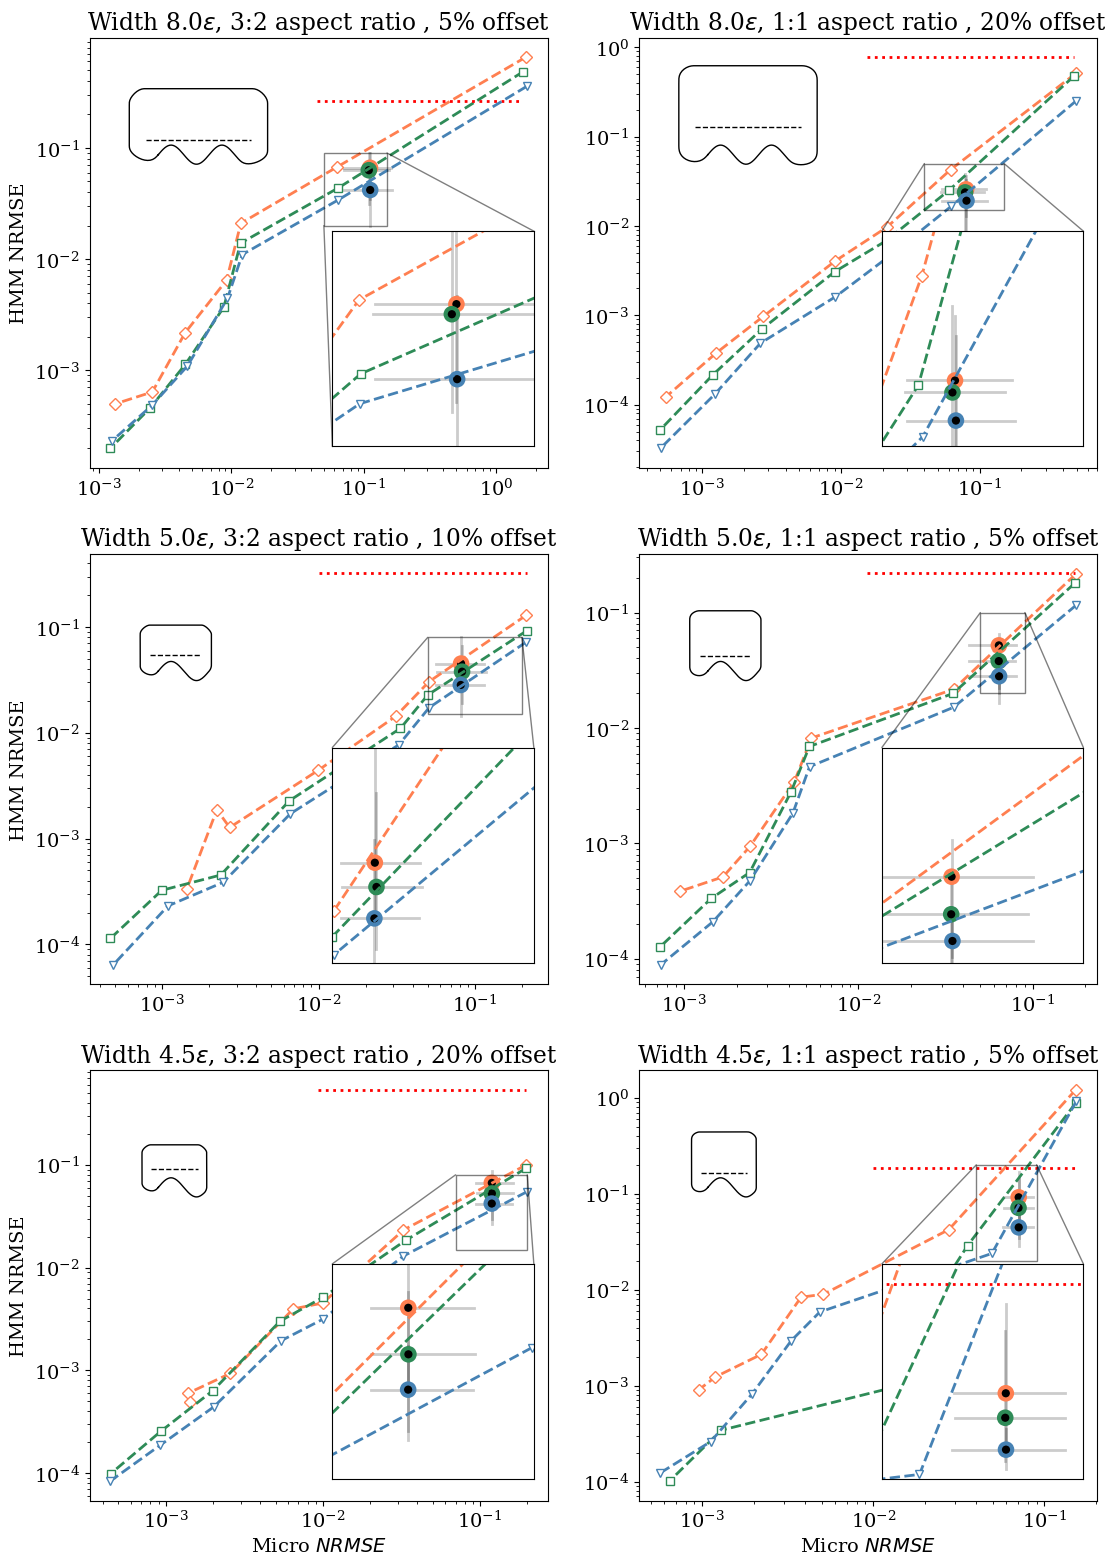

In [29]:
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['lines.linewidth'] = 2

markers = ["D", "s", "v", "^"]
colors = ["coral", "seagreen", "steelblue", "indianred"]
means_f["marker"] = means_f["eps"].apply(lambda x: markers[e_list.index(x)])
means_f["color"] = means_f["eps"].apply(lambda x: colors[e_list.index(x)])


def error_bar(ax, data, x, y, xmin, xmax, ymin, ymax, **kwargs):
    for i, row in data.iterrows():
        ax.plot([row[x], row[x]], [row[ymin], row[ymax]], color="black", alpha=0.2, **kwargs)
        ax.plot([row[xmin], row[xmax]], [row[y], row[y]], color="black", alpha=0.2, **kwargs)
        #ax.fill_between([row[xmin], row[xmax]], [row[ymin], row[ymin]], [row[ymax], row[ymax]], color=row["color"], alpha=0.1, **kwargs)


def plot(ax, data_deep, data_classic):
    error_bar(ax, data_deep, "micro_error", "macro_error", "low_micro", "high_micro", "low_macro", "high_macro", zorder=-1)
    data_deep.plot(x="micro_error", y="macro_error", kind="scatter", c="black", s=80, colorbar=False, ax=ax, marker='o', linewidth=3, edgecolor=data_deep["color"])

    for j, i in enumerate(i_list):
        x = data_classic[data_classic["sim_idx"] == i]["micro_error"]
        y = data_classic[data_classic["sim_idx"] == i]["macro_error"]
        y2 = data_classic[data_classic["sim_idx"] == i]["hmm_error"]
        ax.plot(x, y, markers[j]+"--", color=colors[j], label=f"$e = {e_list[j]}$",  markerfacecolor='white')
        
        if j == 1:
            print(len(x))
            ax.plot([np.sqrt(x.values[-1]*x.values[0]), x.values[0]], [y2.values[0],y2.values[0]], 'r:', label="HMM error", linewidth=2)
    ns_ref = np.logspace(-3, -1) 
    #ax.plot(ns_ref, 2.*ns_ref**1., 'k:', label="O(NMSE^0.5)")

def add_subplot_axes(ax,rect,axisbg='w'):
    fig = plt.gcf()
    box = ax.get_position()
    width = box.width
    height = box.height
    inax_position  = ax.transAxes.transform(rect[0:2])
    transFigure = fig.transFigure.inverted()
    infig_position = transFigure.transform(inax_position)    
    x = infig_position[0]
    y = infig_position[1]
    width *= rect[2]
    height *= rect[3]  # <= Typo was here
    #subax = fig.add_axes([x,y,width,height],facecolor=facecolor)  # matplotlib 2.0+
    subax = fig.add_axes([x,y,width,height])
    x_labelsize = subax.get_xticklabels()[0].get_size()
    y_labelsize = subax.get_yticklabels()[0].get_size()
    x_labelsize *= rect[2]**0.5
    y_labelsize *= rect[3]**0.5
    subax.xaxis.set_tick_params(labelsize=x_labelsize)
    subax.yaxis.set_tick_params(labelsize=y_labelsize)
    return subax

configs = [(8, 0.7, 0.05),(8, 1.0, 0.2), (4.5, 0.7, 0.2), (4.5, 1.0, 0.05)]

configs = [(8.0, 0.7, 0.05, 0.05, 0.15, 0.020, 0.09), \
           (8.0, 1.0, 0.20, 0.04, 0.15, 0.015, 0.05), \
           (5.0, 0.7, 0.10, 0.05, 0.20, 0.015, 0.08), \
           (5.0, 1.0, 0.05, 0.05, 0.09, 0.020, 0.10), \
           (4.5, 0.7, 0.20, 0.07, 0.20, 0.015, 0.08), \
           (4.5, 1.0, 0.05, 0.04, 0.09, 0.020, 0.20)]

x1, x2, y1, y2 = 0.04, 0.16, 0.012, 0.1  # subregion of the original image
#for it, args in enumerate(list(product(w_list, height_list, line_pos_list))[:20]):
#for it, args in enumerate(list(product([4.5, 8], [0.7,1.0], [0.2, 0.05]))[:20]):
aspect_ratio = {0.7: "3:2", 1.0: "1:1"}
plt.figure(figsize=(13, 19))
for it, args in enumerate(configs):
    w, h, lp, x1,x2, y1, y2 = args
    
    stokes_data, info = StokesData.load_from_matlab(f"{run_dir}run_{i}.mat")
    eps = info["eps"]
    micp = StokesMicProb(stokes_data, 0, w*eps, h*w*eps, lp, 8, xDim_reduce=param.xDim, yDim_reduce=param.yDim, n_refine=1)
    
    
    data_deep = means_f[(means_f["width"] == w) & (means_f["height"] == h) & (means_f["line_pos"] == lp)]
    data_classic = runs_classical_less[(runs_classical_less["width"] == w) & (runs_classical_less["height"] == h) & (runs_classical_less["line_pos"] == lp)]
    
    #plt.figure(figsize=(5,4))
    ax = plt.subplot(3, 2, it+1)
    #ax = plt.gca()
    #plt.title(f"Width {w}, height {h}, line pos {lp}")
    plot(ax, data_deep, data_classic)
    #df = df[df["width"] == 4]
    #plt.scatter(df["micro_error"], df["macro_error"], c=np.log(df["eps"]), cmap="viridis", s=10)
    ax.set_xscale("log")
    ax.set_yscale("log")
    if it >= 4:
        ax.set_xlabel("Micro $NRMSE$")
    else:
        ax.set_xlabel("")
    if it % 2 == 0:
        ax.set_ylabel("HMM NRMSE")
    else:
        ax.set_ylabel("")
    #plt.grid(which="both", alpha=0.5)
    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1),
    #        fancybox=False, shadow=False, ncol=5, frameon=False)
    #plt.gca().spines["right"].set_visible(False)
    #plt.gca().spines["top"].set_visible(False)
    #plt.xlim([0.001, .5])
    #plt.ylim([1e-5, 4e-1])

    axins = ax.inset_axes([0.53, 0.05, 0.44, 0.5], xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
    #axins.imshow(Z2, extent=extent, origin="lower")
    plot(axins, data_deep, data_classic)
    axins.set_xlabel("")
    axins.set_ylabel("")
    axins.set_xticks([])
    axins.set_yticks([])
    ax.indicate_inset_zoom(axins, edgecolor="black")

    
    #print(np.unique(data_classic["num_pts"].values))
    ref_val = data_classic[data_classic["num_pts"] == 220][["eps", "hmm_error"]]
    print(ref_val, M_list)
    #plt.tight_layout()
    
    plt.title(f"Width {w:.1f}$\\epsilon$, {aspect_ratio[h]} aspect ratio , {lp*100:.0f}% offset")

    subax = add_subplot_axes(ax, [0.05, 0.55, 0.4, 0.4])
    L = 9*eps
    xp = L/2
    subax.set_xlim([-L+xp,L+xp])
    subax.set_ylim([-L,L])
    #subax.axis("equal")
    subax.axis("off")
    micp.geom.plot(subax, show_rounded=False, show_hline=False, color="black", linewidth=1.)
    subax.plot([np.real(micp.geom.line_left), np.real(micp.geom.line_right)],
                    [np.imag(micp.geom.line_left), np.imag(micp.geom.line_right)], 'k--', linewidth=1.)
    
#plt.tight_layout()
plt.gcf().savefig(f"{figures_dir}coupling_error_new_3x2.pdf")


7
7
7
7
7
7
7
7
7
7
7
7
['GMRES, $\\epsilon = 0.001$', 'GMRES, $\\epsilon = 0.005$', 'HMM error', 'GMRES, $\\epsilon = 0.01$', 'GMRES, $\\epsilon = 0.001$', 'GMRES, $\\epsilon = 0.005$', 'HMM error', 'GMRES, $\\epsilon = 0.01$', 'GMRES, $\\epsilon = 0.001$', 'GMRES, $\\epsilon = 0.005$', 'HMM error', 'GMRES, $\\epsilon = 0.01$', 'GMRES, $\\epsilon = 0.001$', 'GMRES, $\\epsilon = 0.005$', 'HMM error', 'GMRES, $\\epsilon = 0.01$', 'GMRES, $\\epsilon = 0.001$', 'GMRES, $\\epsilon = 0.005$', 'HMM error', 'GMRES, $\\epsilon = 0.01$', 'GMRES, $\\epsilon = 0.001$', 'GMRES, $\\epsilon = 0.005$', 'HMM error', 'GMRES, $\\epsilon = 0.01$']


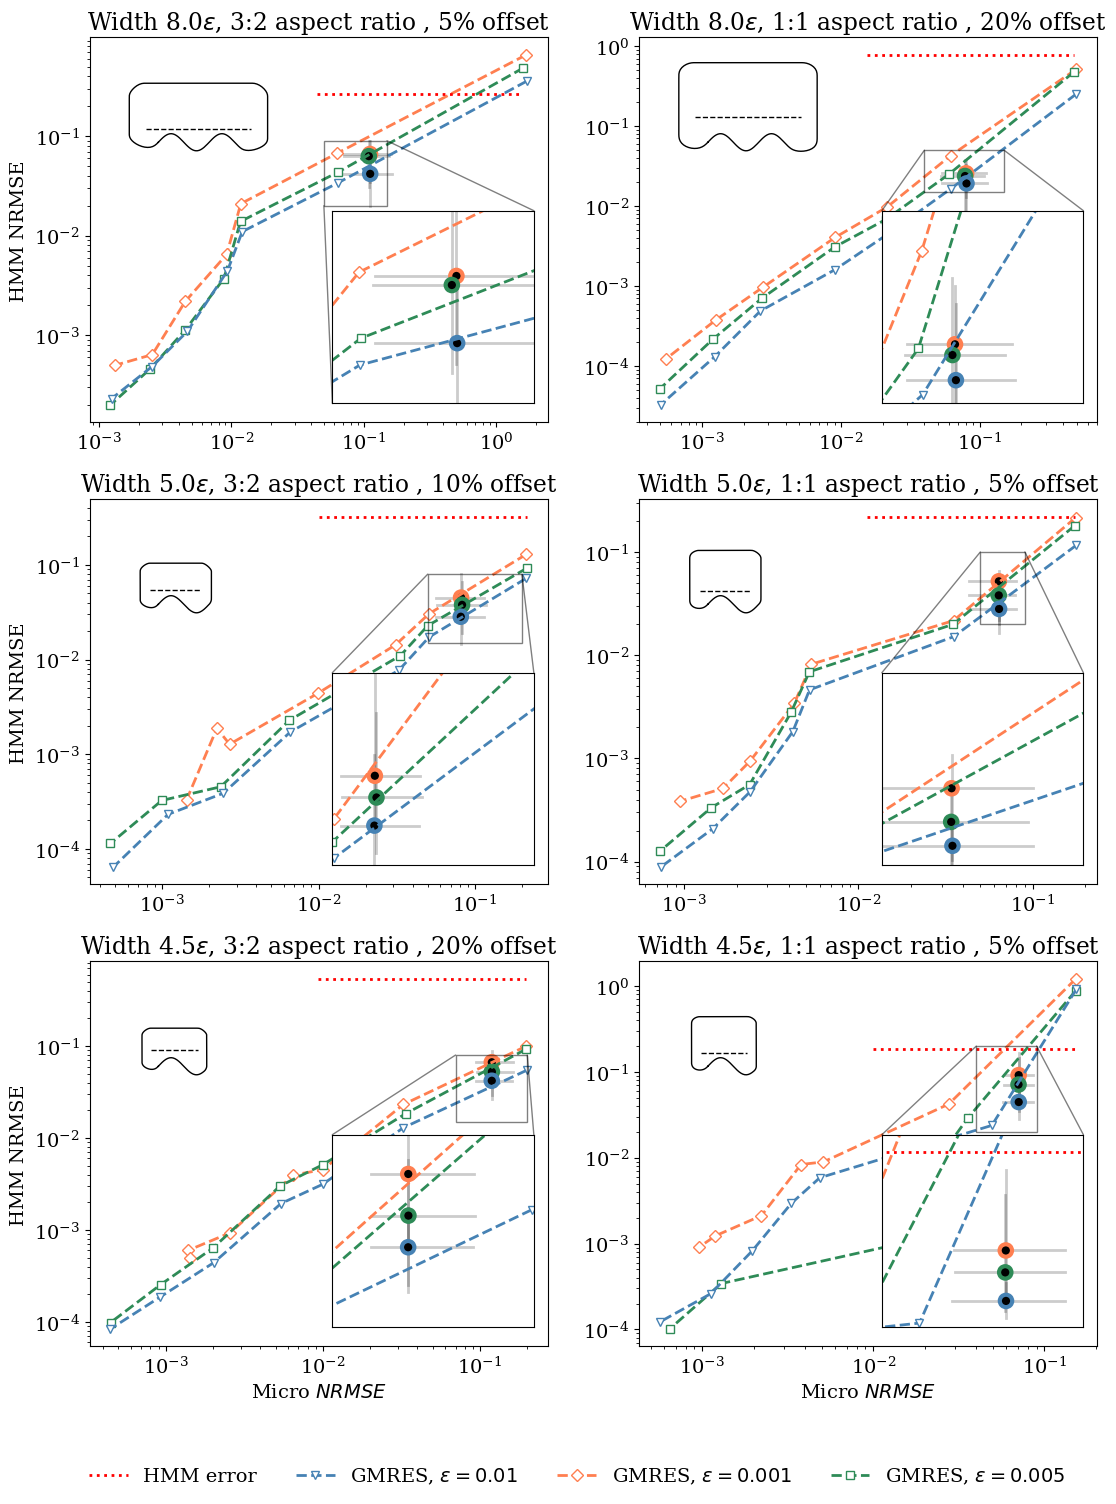

In [48]:
matplotlib.rcParams['font.size'] = 14
matplotlib.rcParams['font.family'] = 'serif'
matplotlib.rcParams['text.usetex'] = False
matplotlib.rcParams['lines.linewidth'] = 2

markers = ["D", "s", "v", "^"]
colors = ["coral", "seagreen", "steelblue", "indianred"]
means_f["marker"] = means_f["eps"].apply(lambda x: markers[e_list.index(x)])
means_f["color"] = means_f["eps"].apply(lambda x: colors[e_list.index(x)])


def error_bar(ax, data, x, y, xmin, xmax, ymin, ymax, **kwargs):
    for i, row in data.iterrows():
        ax.plot([row[x], row[x]], [row[ymin], row[ymax]], color="black", alpha=0.2, **kwargs)
        ax.plot([row[xmin], row[xmax]], [row[y], row[y]], color="black", alpha=0.2, **kwargs)
        #ax.fill_between([row[xmin], row[xmax]], [row[ymin], row[ymin]], [row[ymax], row[ymax]], color=row["color"], alpha=0.1, **kwargs)


def plot(ax, data_deep, data_classic):
    error_bar(ax, data_deep, "micro_error", "macro_error", "low_micro", "high_micro", "low_macro", "high_macro", zorder=-1)
    data_deep.plot(x="micro_error", y="macro_error", kind="scatter", c="black", s=80, colorbar=False, ax=ax, marker='o', linewidth=3, edgecolor=data_deep["color"])

    for j, i in enumerate(i_list[:-1]):
        x = data_classic[data_classic["sim_idx"] == i]["micro_error"]
        y = data_classic[data_classic["sim_idx"] == i]["macro_error"]
        y2 = data_classic[data_classic["sim_idx"] == i]["hmm_error"]
        ax.plot(x, y, markers[j]+"--", color=colors[j], label=f"GMRES, $\\epsilon = {e_list[j]}$",  markerfacecolor='white')
        
        if j == 1:
            print(len(x))
            ax.plot([np.sqrt(x.values[-1]*x.values[0]), x.values[0]], [y2.values[0],y2.values[0]], 'r:', label="HMM error", linewidth=2)
    ns_ref = np.logspace(-3, -1) 
    #ax.plot(ns_ref, 2.*ns_ref**1., 'k:', label="O(NMSE^0.5)")

def add_subplot_axes(ax,rect,axisbg='w'):
    fig = plt.gcf()
    box = ax.get_position()
    width = box.width
    height = box.height
    inax_position  = ax.transAxes.transform(rect[0:2])
    transFigure = fig.transFigure.inverted()
    infig_position = transFigure.transform(inax_position)    
    x = infig_position[0]
    y = infig_position[1]
    width *= rect[2]
    height *= rect[3]  # <= Typo was here
    #subax = fig.add_axes([x,y,width,height],facecolor=facecolor)  # matplotlib 2.0+
    subax = fig.add_axes([x,y,width,height])
    x_labelsize = subax.get_xticklabels()[0].get_size()
    y_labelsize = subax.get_yticklabels()[0].get_size()
    x_labelsize *= rect[2]**0.5
    y_labelsize *= rect[3]**0.5
    subax.xaxis.set_tick_params(labelsize=x_labelsize)
    subax.yaxis.set_tick_params(labelsize=y_labelsize)
    return subax

configs = [(8, 0.7, 0.05),(8, 1.0, 0.2), (4.5, 0.7, 0.2), (4.5, 1.0, 0.05)]

configs = [(8.0, 0.7, 0.05, 0.05, 0.15, 0.020, 0.09), \
           (8.0, 1.0, 0.20, 0.04, 0.15, 0.015, 0.05), \
           (5.0, 0.7, 0.10, 0.05, 0.20, 0.015, 0.08), \
           (5.0, 1.0, 0.05, 0.05, 0.09, 0.020, 0.10), \
           (4.5, 0.7, 0.20, 0.07, 0.20, 0.015, 0.08), \
           (4.5, 1.0, 0.05, 0.04, 0.09, 0.020, 0.20)]

x1, x2, y1, y2 = 0.04, 0.16, 0.012, 0.1  # subregion of the original image
#for it, args in enumerate(list(product(w_list, height_list, line_pos_list))[:20]):
#for it, args in enumerate(list(product([4.5, 8], [0.7,1.0], [0.2, 0.05]))[:20]):
aspect_ratio = {0.7: "3:2", 1.0: "1:1"}
plt.figure(figsize=(13, 17))
for it, args in enumerate(configs):
    w, h, lp, x1,x2, y1, y2 = args
    
    stokes_data, info = StokesData.load_from_matlab(f"{run_dir}run_{i}.mat")
    eps = info["eps"]
    micp = StokesMicProb(stokes_data, 0, w*eps, h*w*eps, lp, 8, xDim_reduce=param.xDim, yDim_reduce=param.yDim, n_refine=1)
    
    
    data_deep = means_f[(means_f["width"] == w) & (means_f["height"] == h) & (means_f["line_pos"] == lp)]
    data_classic = runs_classical_less[(runs_classical_less["width"] == w) & (runs_classical_less["height"] == h) & (runs_classical_less["line_pos"] == lp)]
    
    #plt.figure(figsize=(5,4))
    ax = plt.subplot(3, 2, it+1)
    #ax = plt.gca()
    #plt.title(f"Width {w}, height {h}, line pos {lp}")
    plot(ax, data_deep, data_classic)
    #df = df[df["width"] == 4]
    #plt.scatter(df["micro_error"], df["macro_error"], c=np.log(df["eps"]), cmap="viridis", s=10)
    ax.set_xscale("log")
    ax.set_yscale("log")
    if it >= 4:
        ax.set_xlabel("Micro $NRMSE$")
    else:
        ax.set_xlabel("")
    if it % 2 == 0:
        ax.set_ylabel("HMM NRMSE")
    else:
        ax.set_ylabel("")
    #plt.grid(which="both", alpha=0.5)
    #ax.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1),
    #        fancybox=False, shadow=False, ncol=5, frameon=False)
    #plt.gca().spines["right"].set_visible(False)
    #plt.gca().spines["top"].set_visible(False)
    #plt.xlim([0.001, .5])
    #plt.ylim([1e-5, 4e-1])

    axins = ax.inset_axes([0.53, 0.05, 0.44, 0.5], xlim=(x1, x2), ylim=(y1, y2), xticklabels=[], yticklabels=[])
    #axins.imshow(Z2, extent=extent, origin="lower")
    plot(axins, data_deep, data_classic)
    axins.set_xlabel("")
    axins.set_ylabel("")
    axins.set_xticks([])
    axins.set_yticks([])
    ax.indicate_inset_zoom(axins, edgecolor="black")

    
    #print(np.unique(data_classic["num_pts"].values))
    ref_val = data_classic[data_classic["num_pts"] == 220][["eps", "hmm_error"]]
    #print(ref_val, M_list)
    #plt.tight_layout()
    
    plt.title(f"Width {w:.1f}$\\epsilon$, {aspect_ratio[h]} aspect ratio , {lp*100:.0f}% offset")

    subax = add_subplot_axes(ax, [0.05, 0.55, 0.4, 0.4])
    L = 9*eps
    xp = L/2
    subax.set_xlim([-L+xp,L+xp])
    subax.set_ylim([-L,L])
    #subax.axis("equal")
    subax.axis("off")
    micp.geom.plot(subax, show_rounded=False, show_hline=False, color="black", linewidth=1.)
    subax.plot([np.real(micp.geom.line_left), np.real(micp.geom.line_right)],
                    [np.imag(micp.geom.line_left), np.imag(micp.geom.line_right)], 'k--', linewidth=1.)

fig = plt.gcf()
lines_labels = [ax.get_legend_handles_labels() for ax in fig.axes]
lines, labels = [sum(lol, []) for lol in zip(*lines_labels)]
print(labels)
#fig.legend(lines[2:6], labels[2:6])
# Make legend horizontal
fig.legend(lines[2:6], labels[2:6], loc='upper center', bbox_to_anchor=(0.5, 0.05), ncol=5, frameon=False)


#plt.tight_layout()
plt.gcf().savefig(f"{figures_dir}coupling_error_new_3x2.pdf")


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/data0/emastr/hmm_coupling_paper/big_run_2_1280_sol.npy'

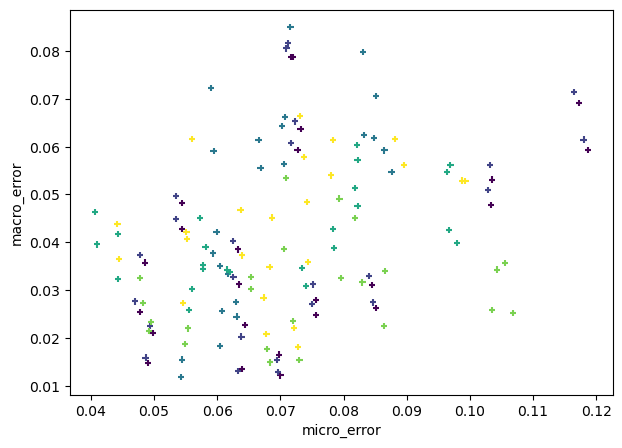

In [8]:

plt.figure(figsize=(7,5))

#def hash_without_seed()
#df_ = df
#df_ = df_[df_["line_pos"]>0.01]
#df_ = df_[df_["width"]>5]
#df_ = df_[df_["net_seed"] < 3]
#df_ = df_[df_["net_type"] == "fno_vanilla_ver4"]
#df_.plot(x="micro_error", y="macro_error", kind="scatter", c="k", cmap="jet", s=10, colorbar=False, ax=plt.gca())


df_ = runs.copy()
df_ = df_[df_["net_type"].isin(["fno_ver3", "fno_ver4", "fno_vanilla_ver4", "fno_vanilla_ver3"])]
df_["net_color"] = df_["net_type"].apply(lambda x: int(x[-1]) if "vanilla" in x else int(x[-1])-2)
df_["net_type_idx"] = df_["net_type"].apply(lambda x: int(x[-1]))
df_["log_eps"] = np.log(df_["eps"])
df_ = df_[df_["line_pos"]>=0.1]
df_ = df_[df_["eps"].isin([0.001, 0.005])]# 0.04])]
df_ = df_[df_["width"]>5]
#df_ = df_[df_["net_seed"] == 3]
df_ = df_[df_["net_type"] == "fno_vanilla_ver3"]
df_.plot(x="micro_error", y="macro_error", kind="scatter", c="net_seed", cmap="viridis", s=20, colorbar=False, ax=plt.gca(), marker="+")


step = [1, 2, 3, 4, 6, 8, 11, 16, 22, 32, 46, 64]#, 128]
M_list = [s * 20 for s in step]
i_list = [2, 42-16, 42, 42+16]#, 74]
e_list = [0.001, 0.005, 0.01, 0.04]
#colors = ["indigo", "tomato", "firebrick", "mediumseagreen"]
colors = ["coral", "seagreen", "steelblue", "indianred"]
markers = ["D", "s", "v", "^"]


micro_error = []
for j, i in enumerate(i_list):
    param_true, _, _, u_true, _, _, _, _, micsol_true = Setup.load_sol(f"{save_dir}big_run_{i}_{M_list[-1]}_sol.npy")
    coupling_error = []
    hmm_error = []
    micro_error = []
    data, info = StokesData.load_from_matlab(f"{run_dir}run_{i}.mat")
    eps = info["eps"]
    X = info["X"]
    Y = info["Y"]
    Uc = info["Uc"]    
    U_interp = PiecewiseInterp2D(X[0], Y[:, 0], Uc)
    #u_true_eps = data["Ux"]
    d = 5
    for s, m in zip(step[:-d], M_list[:-d]):
        param, _, _, u, _, _, _, _, micsol = Setup.load_sol(f"{save_dir}big_run_{i}_{m}_sol.npy")
        #print([s is None for s in Setup.load_sol(f"{save_dir}big_run_{i}_{m}_sol.npy")])
        #print(f"Error for sim {i} with {m} discretisation points")
        (N, M) = u.shape
        u_f = ScaleShiftedBasisProduct.fromFunctionInDomain(lambda x,y: u, data.dom, N, M, FourBasis, ChebBasis)
        u_true_f = ScaleShiftedBasisProduct.fromFunctionInDomain(lambda x,y: u_true, data.dom, N, M, FourBasis, ChebBasis)
        
        x = u_f.reduce_eval(eps, 1).grid()
        u_mask = u_f.reduce_eval(eps, 1).eval_grid().real #u[:, mask]
        u_true_mask = u_true_f.reduce_eval(eps, 1).eval_grid().real #u_true[:, mask]
        u_truest_mask = U_interp(x, x*0+eps)
        
        micro_error.append(max([np.linalg.norm(micsol[n][::s] - micsol_true[n][::step[-1]])/np.linalg.norm(micsol_true[n][::step[-1]]) for n in range(7)]))
        coupling_error.append(np.linalg.norm(u_mask - u_true_mask)/np.linalg.norm(u_true_mask))
        hmm_error.append(np.linalg.norm(u_true_mask - u_truest_mask)/np.linalg.norm(u_true_mask))
    #plt.plot(M_list[:-1], coupling_error, label=f"$epsilon = {eps:.0e}$")
    
    plt.plot(micro_error, coupling_error, markers[j]+"--", color=colors[j], label=f"$e = {e_list[j]}$",  markerfacecolor='white')
    #plt.plot(micro_error, hmm_error, markers[j]+"-", color=colors[j], label=f"$e = {e_list[j]}$",  markerfacecolor='white')



#df = df[df["width"] == 4]
#plt.scatter(df["micro_error"], df["macro_error"], c=np.log(df["eps"]), cmap="viridis", s=10)
ns_ref = np.logspace(-3, -1) 
plt.plot(ns_ref, 2.*ns_ref**1., 'k:', label="O(NMSE^0.5)")
plt.xscale("log")
plt.yscale("log")
plt.xlabel("Maximal $NRMSE$ in micro solution")
plt.ylabel("Normalized error in HMM solution")
#plt.grid(which="both", alpha=0.5)
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.1),
          fancybox=False, shadow=False, ncol=5, frameon=False)
#plt.gca().spines["right"].set_visible(False)
#plt.gca().spines["top"].set_visible(False)
#plt.xlim([0.001, .3])
#plt.ylim([1e-5, 4e-1])
plt.gcf().savefig(f"{figures_dir}coupling_error.png")